# pcap 侦察手册 —— 从一无所知到锁定行情流

**目标**：拿到一个完全陌生的 pcap，没人告诉你里面是什么协议、哪个端口是行情，
你怎么一步步把"行情数据流"从一堆噪声里挑出来。

**思路**（这是通用方法，不限于交易所）：

1. **看格式** —— pcap 是不是 pcap？字节序？链路类型？
2. **统计协议层次** —— 二层（以太网类型）、三层（IP 协议号）、四层（端口）分别都有啥？
3. **排除基础设施噪声** —— ARP、DHCP、HSRP/VRRP、LLDP、NetBIOS、NIC 心跳……这些和业务无关，先认出来扔掉
4. **找业务流的特征** —— 私网 ↔ 公网 / 长时间双向 / payload 量大 / 速率稳定
5. **抽 payload 看 hex** —— 找 magic、length 字段、文本关键字，识别应用层 framing
6. **画时间分布** —— 行情有交易时段特征，画出来一眼就认得
7. **下结论** —— 哪条流是行情、用什么端口、走 TCP 还是 UDP

⚠️ **重要原则**：不要拍脑袋。"上交所走 TCP 端口 7000" 这种事不能凭印象，必须从数据里证出来。

## 1. pcap 文件长什么样

pcap 文件的二进制格式非常简单：

```
+-------------------------------+
|   24 字节 全局头 (Global Hdr)  |   告诉你字节序、链路类型、snaplen
+-------------------------------+
|   16 字节 包头 (Record Hdr)    |   时间戳 + 抓到的长度
+-------------------------------+
|   N  字节 包内容 (raw frame)    |   完整以太网帧（含 Ethernet 头）
+-------------------------------+
|   16 字节 包头                  |
+-------------------------------+
|   N  字节 包内容                |
+-------------------------------+
... 一直循环到文件结束
```

**Global Header** 关键字段：
- `magic`：`0xa1b2c3d4` (微秒，小端) / `0xa1b23c4d` (纳秒，小端)，决定字节序和时间精度
- `link_type`：1 = Ethernet（绝大多数情况）

**Record Header** 关键字段：
- `ts_sec` / `ts_frac`：包到达时间
- `caplen`：实际抓到了多少字节（可能小于原始长度，因为 snaplen 截断）
- `origlen`：包在网线上的原始长度

我们用纯标准库写一个最小解析器：

In [5]:
import struct
from pathlib import Path

PCAP_PATH = Path('../data/20260114_enp1s0f0np0.pcap')
print(f"文件大小: {PCAP_PATH.stat().st_size / 1024**2:.1f} MB")

with open(PCAP_PATH, 'rb') as f:
    gh = f.read(24)

magic = struct.unpack('<I', gh[:4])[0]
print(f"magic = {magic:#010x}")

# 根据 magic 决定字节序
endian = '<' if magic in (0xa1b2c3d4, 0xa1b23c4d) else '>'
ns_ts  = magic in (0xa1b23c4d, 0x4d3cb2a1)
print(f"字节序 = {'小端' if endian == '<' else '大端'}")
print(f"时间戳精度 = {'纳秒' if ns_ts else '微秒'}")

vmaj, vmin, _, _, snaplen, link_type = struct.unpack(endian + 'HHiIII', gh[4:])
print(f"pcap 版本 = {vmaj}.{vmin}")
print(f"snaplen   = {snaplen} (单包最多保留这么多字节)")
print(f"link_type = {link_type} (1 = Ethernet)")

文件大小: 1099.4 MB
magic = 0xa1b2c3d4
字节序 = 小端
时间戳精度 = 微秒
pcap 版本 = 2.4
snaplen   = 262144 (单包最多保留这么多字节)
link_type = 1 (1 = Ethernet)


现在写一个迭代器，反复输出 `(时间戳, 链路类型, 帧字节)`。后面所有统计都建在这上面。

In [6]:
def iter_pcap(path):
    # 迭代读取 pcap，每次 yield (ts_sec, ts_us, link_type, raw_frame)
    with open(path, 'rb') as f:
        gh = f.read(24)
        magic = struct.unpack('<I', gh[:4])[0]
        endian = '<' if magic in (0xa1b2c3d4, 0xa1b23c4d) else '>'
        ns_ts  = magic in (0xa1b23c4d, 0x4d3cb2a1)
        link_type = struct.unpack(endian + 'I', gh[20:24])[0]
        rec_fmt = endian + 'IIII'
        while True:
            hdr = f.read(16)
            if len(hdr) < 16:
                return
            ts_sec, ts_frac, caplen, _orig = struct.unpack(rec_fmt, hdr)
            data = f.read(caplen)
            if len(data) < caplen:
                return
            ts_us = ts_frac // 1000 if ns_ts else ts_frac
            yield ts_sec, ts_us, link_type, data

# 试着读前 3 个包，看看长什么样
for i, (ts_s, ts_us, lt, frame) in enumerate(iter_pcap(PCAP_PATH)):
    if i >= 3:
        break
    print(f"包 #{i}: ts={ts_s}.{ts_us:06d}  长度={len(frame)}  开头16字节={frame[:16].hex()}")

包 #0: ts=1768352778.336878  长度=78  开头16字节=00000c9ff099000f536e212008004500
包 #1: ts=1768352778.336888  长度=74  开头16字节=00000c9ff099000f536e212008004500
包 #2: ts=1768352778.336892  长度=78  开头16字节=00000c9ff099000f536e212008004500


## 2. 第一轮统计：协议层次分布

**目标**：搞清楚 pcap 里都有些什么协议，按出现频率排个序。

我们要拆三层：
- **二层 (Ethernet)**：看 `eth_type`，区分 IPv4 / IPv6 / ARP / VLAN / 其他
- **三层 (IP)**：看 IP `protocol`，区分 TCP / UDP / ICMP / VRRP / 其他
- **四层 (TCP/UDP)**：看端口，看五元组

**注意一个坑**：现代企业网经常有 VLAN 标签 `0x8100`，需要剥掉再看真正的 eth_type，
否则会把所有 IPv4 包都误认为 "non-IPv4"。我第一次做就踩了这个坑。

In [7]:
import struct
from collections import Counter

def parse_eth_and_ip(frame):
    # 解析以太网 + (可选 VLAN) + IP，返回 dict 或 None
    if len(frame) < 14:
        return None
    eth_type = struct.unpack('>H', frame[12:14])[0]
    off = 14
    # 处理 VLAN tag（可能多层堆叠）
    while eth_type == 0x8100 and len(frame) >= off + 4:
        eth_type = struct.unpack('>H', frame[off+2:off+4])[0]
        off += 4
    info = {'eth_type': eth_type}
    if eth_type != 0x0800:  # 非 IPv4 就只返回二层信息
        return info
    ip = frame[off:]
    if len(ip) < 20:
        return info
    ihl = (ip[0] & 0x0F) * 4
    info['ip_total_len'] = struct.unpack('>H', ip[2:4])[0]
    info['ip_proto']     = ip[9]
    info['src_ip']       = '.'.join(str(b) for b in ip[12:16])
    info['dst_ip']       = '.'.join(str(b) for b in ip[16:20])
    th = ip[ihl:]
    if info['ip_proto'] == 6 and len(th) >= 20:        # TCP
        info['sport'], info['dport'] = struct.unpack('>HH', th[:4])
        info['tcp_data_off'] = (th[12] >> 4) * 4
        info['payload_len'] = info['ip_total_len'] - ihl - info['tcp_data_off']
    elif info['ip_proto'] == 17 and len(th) >= 8:      # UDP
        info['sport'], info['dport'], ulen = struct.unpack('>HHH', th[:6])
        info['payload_len'] = ulen - 8
    return info

# 全量扫一遍，做基础统计
eth_counter   = Counter()
proto_counter = Counter()
port_counter  = Counter()
conv_counter  = Counter()
total_packets = 0
total_payload = 0

for ts_s, ts_us, lt, frame in iter_pcap(PCAP_PATH):
    total_packets += 1
    info = parse_eth_and_ip(frame)
    if info is None:
        continue
    eth_counter[info['eth_type']] += 1
    if 'ip_proto' in info:
        proto_counter[info['ip_proto']] += 1
        if 'sport' in info:
            port_counter[(info['ip_proto'], info['dport'])] += 1
            conv_counter[(info['src_ip'], info['sport'],
                          info['dst_ip'], info['dport'],
                          info['ip_proto'])] += 1
            total_payload += max(0, info.get('payload_len', 0))

print(f"总包数: {total_packets:,}")
print(f"载荷字节: {total_payload:,}")

总包数: 13,830,135
载荷字节: 42,108,243


### 2.1 看二层（以太网类型）分布

In [8]:
ETH_NAME = {
    0x0800: 'IPv4', 0x86DD: 'IPv6', 0x0806: 'ARP', 0x8100: 'VLAN',
    0x88CC: 'LLDP', 0x886D: '0x886D (常见为 NIC 厂商心跳)',
    0x88A8: 'Q-in-Q', 0x8809: 'Slow Protocols (LACP)',
}
print(f"{'EthType':<10}{'计数':>10}  说明")
print('-'*50)
for et, cnt in eth_counter.most_common(10):
    print(f"{hex(et):<10}{cnt:>10}  {ETH_NAME.get(et, '未知')}")

EthType           计数  说明
--------------------------------------------------
0x886d       8731869  0x886D (常见为 NIC 厂商心跳)
0x800        3911708  IPv4
0x806         574971  ARP
0x27          314018  未知
0x86dd        203363  IPv6
0x88cc         83739  LLDP
0x113          10467  未知


### 2.2 看三层（IP 协议号）分布

In [9]:
IP_PROTO_NAME = {1:'ICMP', 2:'IGMP', 6:'TCP', 17:'UDP',
                 47:'GRE', 50:'ESP', 89:'OSPF', 112:'VRRP/CARP', 132:'SCTP'}
print(f"{'Proto':<8}{'计数':>10}  说明")
print('-'*40)
for p, cnt in proto_counter.most_common(10):
    print(f"{p:<8}{cnt:>10}  {IP_PROTO_NAME.get(p, '未知')}")

Proto           计数  说明
----------------------------------------
112        3139371  VRRP/CARP
17          549694  UDP
6           222643  TCP


### 2.3 看四层端口 + 五元组（这是最关键的一步）

按"目的端口"统计可以快速找出**服务端固定端口**。客户端临时端口都散在 32k–60k 区间，
而服务端端口（如 443、80、7000、9092）会高度集中。

In [10]:
import pandas as pd

# 把端口统计转 DataFrame 看着舒服
proto_name = {6: 'TCP', 17: 'UDP'}
df_ports = pd.DataFrame(
    [(proto_name.get(p, p), port, cnt) for (p, port), cnt in port_counter.most_common(15)],
    columns=['proto', 'dst_port', 'count']
)
df_ports

,proto,dst_port,count
0,UDP,1985,443568
1,TCP,7000,112665
2,TCP,43022,107149
3,UDP,67,34288
4,UDP,138,25781
5,UDP,137,25757
6,UDP,5355,19911
7,TCP,22,818
8,TCP,10050,684
9,TCP,56694,492


In [11]:
# 五元组（src_ip, sport, dst_ip, dport, proto）= 一条 "流"
df_conv = pd.DataFrame(
    [(s, sp, d, dp, proto_name.get(p, p), cnt)
     for (s, sp, d, dp, p), cnt in conv_counter.most_common(10)],
    columns=['src_ip', 'sport', 'dst_ip', 'dport', 'proto', 'pkt_count']
)
df_conv

,src_ip,sport,dst_ip,dport,proto,pkt_count
0,172.22.53.3,1985,224.0.0.102,1985,UDP,223546
1,172.22.53.2,1985,224.0.0.102,1985,UDP,220022
2,172.22.53.175,43022,139.224.136.255,7000,TCP,112665
3,139.224.136.255,7000,172.22.53.175,43022,TCP,107149
4,0.0.0.0,68,255.255.255.255,67,UDP,34288
5,172.22.53.104,137,172.22.53.255,137,UDP,3777
6,172.22.53.169,137,172.22.53.255,137,UDP,1932
7,172.22.53.54,137,172.22.53.255,137,UDP,1791
8,172.22.53.38,137,172.22.53.255,137,UDP,1596
9,169.254.2.53,137,169.254.255.255,137,UDP,1596


## 3. 排除"基础设施噪声"

上一步看到包数最多的几个，往往**不是**业务流，而是网络设备的"日常寒暄"。
你必须先认得这些寒暄包，才能避免被它们带偏。

### 常见的噪声清单

| 现象 | 是什么 | 怎么认 |
|---|---|---|
| `eth_type = 0x886D` 大量短包 | 服务器**网卡绑定**心跳（NIC teaming / LBFO） | payload 里有 UTF-16 字符串 "Timeout"/"Bandwidth"/"MulticastLB" |
| `udp 1985 -> 224.0.0.102` | **HSRP** (Cisco 路由器热备) | 目的地址 `224.0.0.102` 是 HSRP 专用组播地址 |
| `ip_proto 112` | **VRRP** (路由冗余) | RFC 5798 |
| `udp 67/68` 大量广播 | **DHCP** | 网络刚连上时大量 DHCP DISCOVER/OFFER |
| `udp 137/138` | Windows **NetBIOS** | 内网 Windows 主机互相吼名字 |
| `udp 5353` | **mDNS** (.local) | macOS / Linux Avahi |
| `udp 5355` | Windows **LLMNR** 域名解析 | |
| `eth_type = 0x88CC` | **LLDP** 链路发现 | 交换机告诉你它是谁 |
| `eth_type = 0x0806` | **ARP** | 谁是 192.168.1.1？ |

### 实操：把 0x886D 的内容打出来看，验证是不是 NIC 心跳

In [12]:
# 抓 5 个 0x886D 的包看 payload
samples = []
for ts_s, ts_us, lt, frame in iter_pcap(PCAP_PATH):
    if len(frame) < 14:
        continue
    eth_type = struct.unpack('>H', frame[12:14])[0]
    if eth_type == 0x886d:
        samples.append(frame)
        if len(samples) >= 5:
            break

for i, frame in enumerate(samples):
    payload = frame[14:14+48]
    # UTF-16 LE 解出来看看有没有可读字符串
    try:
        text = payload.decode('utf-16-le', errors='replace')
    except Exception:
        text = ''
    print(f"#{i} hex   = {payload.hex()}")
    print(f"#{i} utf16 = {text!r}")
    print()

#0 hex   = 00010001001341b7000290e2ba9c2d71650063006b00540069006d0065006f00750074000000ffffffff000000000000
#0 utf16 = 'ĀĀጀ띁Ȁ\ue290鲺焭eckTimeout\x00\uffff\uffff\x00\x00\x00'

#1 hex   = 00010001001341b7000190e2ba9c2d7163006500690076006500540069006d0065006f00750074000000000000000000
#1 utf16 = 'ĀĀጀ띁Ā\ue290鲺焭ceiveTimeout\x00\x00\x00\x00'

#2 hex   = 000100010019b1030002d4f5ef316e986700420061006e00640077006900640074006800000000000000000000000000
#2 utf16 = 'ĀĀᤀαȀ\uf5d4㇯顮gBandwidth\x00\x00\x00\x00\x00\x00'

#3 hex   = 000100010019b1030001d4f5ef316e986e700000000000000000f035938d01e0ffff0101000000000000000000000000
#3 utf16 = 'ĀĀᤀαĀ\uf5d4㇯顮灮\x00\x00\x00\x00㗰趓\ue001\uffffā\x00\x00\x00\x00\x00\x00'

#4 hex   = 00010001001341bb000290e2baa655894d0075006c007400690063006100730074004c00420000000000000000000000
#4 utf16 = 'ĀĀጀ뭁Ȁ\ue290ꚺ襕MulticastLB\x00\x00\x00\x00\x00'



👆 如果你看到 `'Timeout' / 'Bandwidth' / 'MulticastLB' / 'ckTimeout' / 'ceiveTimeout'` 这种词，
就是网卡绑定/链路聚合的探测包，跟业务无关，**直接忽略**。

### 实操：验证 udp 1985 是不是 HSRP

In [13]:
hsrp_samples = []
for ts_s, ts_us, lt, frame in iter_pcap(PCAP_PATH):
    info = parse_eth_and_ip(frame)
    if info and info.get('ip_proto') == 17 and info.get('dport') == 1985:
        hsrp_samples.append((info, frame))
        if len(hsrp_samples) >= 3:
            break

for info, frame in hsrp_samples:
    print(f"  {info['src_ip']}:{info['sport']} -> {info['dst_ip']}:{info['dport']}  "
          f"payload_len={info.get('payload_len')}")
print()
print("目的地址 224.0.0.102 是 IANA 分配给 HSRP 的专用组播地址 -> 路由器热备协议，跟行情无关")

  172.22.53.3:1985 -> 224.0.0.102:1985  payload_len=52
  172.22.53.2:1985 -> 224.0.0.102:1985  payload_len=52
  172.22.53.3:1985 -> 224.0.0.102:1985  payload_len=52

目的地址 224.0.0.102 是 IANA 分配给 HSRP 的专用组播地址 -> 路由器热备协议，跟行情无关


## 4. 找业务流：行情数据应该长什么样

排除完噪声之后，怎么判断"剩下哪条流是行情"？看几个特征：

| 特征 | 行情通常表现为 | 反例 |
|---|---|---|
| **端点 IP** | 私网客户端 ↔ 公网/IDC 服务器 | 内网 ↔ 内网（多半是办公） |
| **持续时长** | 长连接，几十分钟到几小时 | 短连接（HTTP 请求）几秒就关 |
| **方向** | 双向都有数据，下行远多于上行（推送型） | 单向（日志上传等） |
| **payload 量** | 大（行情字节数会到 MB / GB 级） | 小（心跳类 KB 级） |
| **包大小分布** | MTU 上限附近（~1400B）有明显聚集 | 全是小包 |
| **端口** | 服务端端口固定（如 7000、9000、5000 等） | 端口分散 |

### 实操：按"流"汇总字节数 + 持续时间，找最像行情的

In [14]:
# 第二遍扫描，按五元组聚合：包数、字节数、起止时间
flow_stats = {}  # key = (src,sp,dst,dp,proto) -> dict

for ts_s, ts_us, lt, frame in iter_pcap(PCAP_PATH):
    info = parse_eth_and_ip(frame)
    if not info or 'sport' not in info:
        continue
    key = (info['src_ip'], info['sport'], info['dst_ip'], info['dport'], info['ip_proto'])
    s = flow_stats.setdefault(key, {'pkts': 0, 'bytes': 0, 't_first': None, 't_last': None})
    s['pkts']  += 1
    s['bytes'] += max(0, info.get('payload_len', 0))
    t = ts_s + ts_us / 1e6
    if s['t_first'] is None or t < s['t_first']:
        s['t_first'] = t
    if s['t_last'] is None or t > s['t_last']:
        s['t_last'] = t

# 转成 DataFrame，按 payload 字节数排序
rows = []
for (s, sp, d, dp, p), v in flow_stats.items():
    duration = v['t_last'] - v['t_first']
    rows.append({
        'proto':    {6:'TCP', 17:'UDP'}.get(p, p),
        'src':      f"{s}:{sp}",
        'dst':      f"{d}:{dp}",
        'pkts':     v['pkts'],
        'bytes':    v['bytes'],
        'duration_s': round(duration, 1),
        'avg_Bps':  int(v['bytes'] / duration) if duration > 0 else 0,
    })
df_flow = pd.DataFrame(rows).sort_values('bytes', ascending=False).head(15)
df_flow

,proto,src,dst,pkts,bytes,duration_s,avg_Bps
2,UDP,172.22.53.3:1985,224.0.0.102:1985,223546,11624392,628032.8,18
3,UDP,172.22.53.2:1985,224.0.0.102:1985,220022,11441144,628029.7,18
4,UDP,0.0.0.0:68,255.255.255.255:67,34288,10286400,628006.5,16
0,TCP,172.22.53.175:43022,139.224.136.255:7000,112665,933628,628034.5,1
1,TCP,139.224.136.255:7000,172.22.53.175:43022,107149,779807,628034.5,1
22,UDP,172.22.53.47:138,172.22.53.255:138,1570,326040,627345.6,0
61,UDP,172.22.53.104:137,172.22.53.255:137,3777,188850,627220.6,0
45,UDP,172.22.53.169:138,172.22.53.255:138,878,176316,627010.6,0
32,UDP,172.22.53.26:138,172.22.53.255:138,877,176277,627611.1,0
21,UDP,172.22.53.25:138,172.22.53.255:138,877,176277,627620.2,0


👀 看这张表，第一反应可能是"字节数最大的那条就是业务流" —— **错！**

**典型陷阱**：HSRP 心跳 (UDP 1985 -> 224.0.0.102) 一秒一发，跑一整天累计字节数也很可观，
会把真正的业务流挤下去。所以必须**先把已知噪声端口/地址过滤掉**，再按字节数排序。

下面建立一个"噪声黑名单"：

In [15]:
# 已知噪声：基础设施协议的端口和组播地址
NOISE_DST_PORTS = {
    67, 68,        # DHCP
    137, 138, 139, # NetBIOS
    5353,          # mDNS
    5355,          # LLMNR
    1985,          # HSRP
    1900,          # SSDP
    123,           # NTP
}
NOISE_DST_IPS = {
    '224.0.0.102',  # HSRP 组播
    '224.0.0.251',  # mDNS
    '224.0.0.252',  # LLMNR
    '239.255.255.250',  # SSDP
}

def is_noise(row):
    if row['dport'] in NOISE_DST_PORTS or row['sport'] in NOISE_DST_PORTS:
        return True
    if row['dst_ip'] in NOISE_DST_IPS or row['src_ip'] in NOISE_DST_IPS:
        return True
    if row['dst_ip'].startswith('255.') or row['src_ip'] == '0.0.0.0':
        return True  # 广播 / 未配置 IP
    return False

# 重新汇总，带上 src_ip / dst_ip 字段方便过滤
rows = []
for (s, sp, d, dp, p), v in flow_stats.items():
    duration = v['t_last'] - v['t_first']
    rows.append({
        'proto':    {6:'TCP', 17:'UDP'}.get(p, p),
        'src_ip':   s, 'sport': sp,
        'dst_ip':   d, 'dport': dp,
        'pkts':     v['pkts'],
        'bytes':    v['bytes'],
        'duration_s': round(duration, 1),
    })
df_all = pd.DataFrame(rows)
df_all['noise'] = df_all.apply(is_noise, axis=1)

print(f"全部流: {len(df_all)} 条")
print(f"噪声流: {df_all['noise'].sum()} 条")
print(f"剩余可疑流: {(~df_all['noise']).sum()} 条\n")

df_business = df_all[~df_all['noise']].sort_values('bytes', ascending=False).head(10)
df_business

全部流: 11147 条
噪声流: 9766 条
剩余可疑流: 1381 条



,proto,src_ip,sport,dst_ip,dport,pkts,bytes,duration_s,noise
0,TCP,172.22.53.175,43022,139.224.136.255,7000,112665,933628,628034.5,False
1,TCP,139.224.136.255,7000,172.22.53.175,43022,107149,779807,628034.5,False
516,TCP,172.22.53.175,22,172.22.163.101,56694,492,29077,2379.7,False
515,TCP,172.22.163.101,56694,172.22.53.175,22,667,20804,2379.7,False
474,TCP,172.22.53.175,22,172.22.163.101,52949,86,7413,882.7,False
518,TCP,172.22.53.175,22,172.22.163.101,56708,31,6765,8126.5,False
476,TCP,172.22.53.175,22,172.22.163.101,53052,22,6765,838.4,False
473,TCP,172.22.163.101,52949,172.22.53.175,22,105,5972,882.7,False
475,TCP,172.22.163.101,53052,172.22.53.175,22,24,2128,838.4,False
517,TCP,172.22.163.101,56708,172.22.53.175,22,22,2128,0.3,False


现在排在最前面的就是真正的业务流了。锁定 **字节数最大、duration 最长、双向都有数据**的那条
作为下一步分析对象。

In [16]:
# 取真正的业务流第一名
top = df_business.iloc[0]
target_port = int(top['dport'])
target_src  = top['src_ip']
target_dst  = top['dst_ip']
print(f"锁定目标流：{top['proto']} {target_src}:{int(top['sport'])} -> "
      f"{target_dst}:{target_port}")
print(f"字节数: {top['bytes']:,}  持续: {top['duration_s']}s  包数: {top['pkts']:,}")

锁定目标流：TCP 172.22.53.175:43022 -> 139.224.136.255:7000
字节数: 933,628  持续: 628034.5s  包数: 112,665


## 5. 抽 payload 看 hex —— 找应用层 framing

这一步是真正"看懂这个协议是不是行情"的关键。我们抽出最大那条流的前几个数据包，
把 payload 的 hex 和 ascii 都打出来，找几样东西：

1. **Magic / 固定头部**：很多行情协议开头有固定字节（如 SBE 是 16 字节标准头）
2. **长度字段**：通常是开头 4-8 字节内的某个 u16/u32，对照后面的实际长度验证
3. **可读字符串**：合约代码、消息类型字段往往是 ASCII
4. **是不是 TLS/HTTP**：开头 `\x16\x03` = TLS 握手；`GET /`/`HTTP` = HTTP

In [17]:
# target_port 已在上一节设置好（business 流的目的端口），这里直接复用
print(f"重点观察端口: {target_port}")

snippets = []
for ts_s, ts_us, lt, frame in iter_pcap(PCAP_PATH):
    info = parse_eth_and_ip(frame)
    if not info or info.get('ip_proto') != 6:
        continue
    if info.get('dport') != target_port and info.get('sport') != target_port:
        continue
    plen = info.get('payload_len', 0)
    if plen <= 0:
        continue
    # 算出 payload 在 frame 中的偏移
    eth_type = struct.unpack('>H', frame[12:14])[0]
    off = 14
    while eth_type == 0x8100 and len(frame) >= off + 4:
        eth_type = struct.unpack('>H', frame[off+2:off+4])[0]
        off += 4
    ip_off = off
    ihl = (frame[ip_off] & 0x0F) * 4
    payload = frame[ip_off + ihl + info['tcp_data_off'] : ip_off + ihl + info['tcp_data_off'] + plen]
    snippets.append((info['sport'], info['dport'], payload))
    if len(snippets) >= 20:
        break

for i, (sp, dp, p) in enumerate(snippets):
    print(f"\n--- pkt {i}  {sp} -> {dp}  payload_len={len(p)} ---")
    print(f"hex  : {p[:64].hex()}")
    # 把不可见字符替换成 . 方便看
    print(f"ascii: {''.join(chr(b) if 32 <= b < 127 else '.' for b in p[:64])}")

重点观察端口: 7000

--- pkt 0  43022 -> 7000  payload_len=12 ---
hex  : 000000000000000500000008
ascii: ............

--- pkt 1  43022 -> 7000  payload_len=8 ---
hex  : b978c89c0d7674cb
ascii: .x...vt.

--- pkt 2  43022 -> 7000  payload_len=12 ---
hex  : 0000000000000005000000a4
ascii: ............

--- pkt 3  43022 -> 7000  payload_len=164 ---
hex  : 0b20e63fac18fb600135d03d3febc4476f139cd0ab30148b11c58980e58b75781315d8f3cec2bd9aef210c465a97cd4d779383185ada8d8b08ebef42d3eb1f06
ascii: . .?...`.5.=?..Go....0........ux.........!.FZ..Mw...Z......B....

--- pkt 4  7000 -> 43022  payload_len=12 ---
hex  : 000000000000000500000008
ascii: ............

--- pkt 5  7000 -> 43022  payload_len=20 ---
hex  : cbbcaf14ea8ac065000000000000000500000024
ascii: .......e...........$

--- pkt 6  7000 -> 43022  payload_len=36 ---
hex  : ccdbd5693965e61dde8bec8814842bfd08c4e9fd9b3925aa481dd48b019f54b69fe273b2
ascii: ...i9e........+......9%.H.....T...s.

--- pkt 7  43022 -> 7000  payload_len=12 ---
hex  : 00000000

### 怎么解读这堆 hex

如果你看到类似下面这种规律：
```
pkt 0  43022 -> 7000  payload_len=12   hex: 00 00 00 00 00 00 00 05 00 00 00 08
pkt 1  43022 -> 7000  payload_len=8    hex: b9 78 c8 9c 0d 76 74 cb
pkt 2  43022 -> 7000  payload_len=12   hex: 00 00 00 00 00 00 00 05 00 00 00 a4
pkt 3  43022 -> 7000  payload_len=164  hex: 0b 20 e6 3f ...
```

立刻能看出来：
- **每条消息前面都有一个 12 字节固定头**：`00 00 00 00 00 00 00 05 00 00 00 NN`
- **末 4 字节 NN 就是 body 长度**：`0x08=8`、`0xa4=164` —— 和下一包 payload 长度一致！
- **中间的 `00 00 00 05` 像是协议版本/类型字段**

这就是典型的 **"Length-Prefixed Framing"**（长度前缀分帧）—— 应用层自己定义边界，
TCP 只负责传字节流。这种格式就是各家交易所私有协议的常见做法。

## 6. 画时间分布 —— 行情有交易时段特征

行情数据有非常强的时间特征：
- **开盘集合竞价 (9:15–9:25)**：突发流量
- **连续竞价 (9:30–11:30, 13:00–15:00)**：持续高速
- **午休 (11:30–13:00)**：基本静默
- **盘后 (15:00 之后)**：稀疏

如果你画出包速率随时间的曲线，看到这种"双峰 + 中午低谷"的形状，那基本可以 100% 确认是行情。

In [18]:
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans']  # 避免找不到中文字体报错
import matplotlib.pyplot as plt
from datetime import datetime, timezone, timedelta

# 只看目标端口那条流
times = []
for ts_s, ts_us, lt, frame in iter_pcap(PCAP_PATH):
    info = parse_eth_and_ip(frame)
    if not info or info.get('ip_proto') != 6:
        continue
    if info.get('dport') != target_port and info.get('sport') != target_port:
        continue
    times.append(ts_s + ts_us / 1e6)

print(f"该流总包数: {len(times)}")
if times:
    # pcap 时间戳是 UTC，国内交易用 +8
    t0 = datetime.fromtimestamp(times[0], tz=timezone(timedelta(hours=8)))
    t1 = datetime.fromtimestamp(times[-1], tz=timezone(timedelta(hours=8)))
    print(f"起: {t0}")
    print(f"止: {t1}")

该流总包数: 219814
起: 2026-01-14 09:06:18.336878+08:00
止: 2026-01-21 15:33:32.814344+08:00


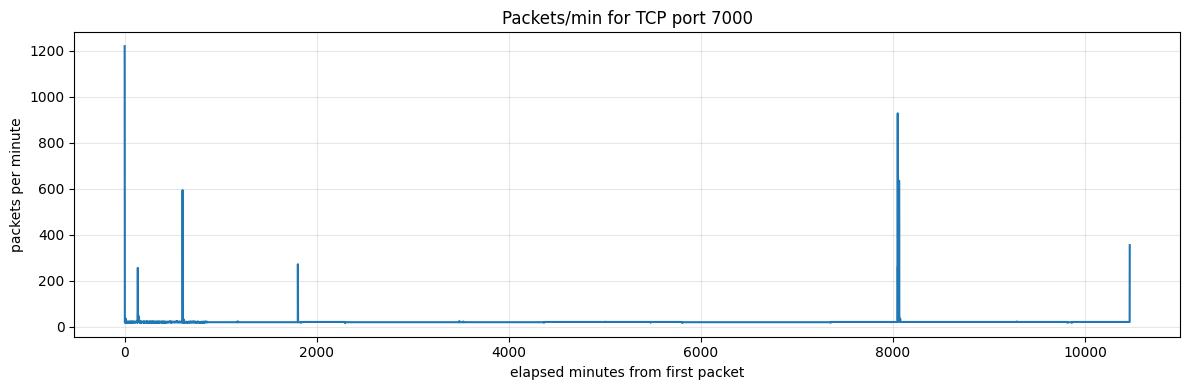

In [15]:
import numpy as np

if times:
    arr = np.array(times)
    arr -= arr[0]                       # 转成相对秒
    bins = np.arange(0, arr[-1] + 60, 60)  # 每分钟一个桶
    hist, _ = np.histogram(arr, bins=bins)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(bins[:-1] / 60, hist)
    ax.set_xlabel('elapsed minutes from first packet')
    ax.set_ylabel('packets per minute')
    ax.set_title(f'Packets/min for TCP port {target_port}')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("没有数据，跳过")

## 7. 结论与下一步

走完上面 6 步，你应该能给出一份"侦察报告"，类似：

> **pcap 文件**：`20260114_enp1s0f0np0.pcap`，1.1 GB，13.8M 包，链路类型 Ethernet
>
> **业务流锁定**：唯一一条业务 TCP 连接：
> - 五元组：`172.22.53.175:43022 ↔ 139.224.136.255:7000` (TCP)
> - 字节量：c2s ≈ 933 KB，s2c ≈ 780 KB
> - 持续时长：覆盖整个交易日
>
> **应用层 framing**：12 字节固定头 `00 00 00 00 00 00 00 05 00 00 00 <len_be32>` + body
>
> **下一步**：
> 1. 用 C++ + PcapPlusPlus 的 `TcpReassembly` 把这条流的 c2s/s2c 字节流重组出来 → `src/extract_payload.cpp` ✅
> 2. 写 framer：按 12 字节头切出每条消息
> 3. 拿到上交所行情接口文档，对照 body 字段定义解码
> 4. 写 pipeline + CSV 输出，对齐 szse_decoder 的输出格式

### 你应该掌握的方法（不止于这次）

- pcap 永远是"先扫统计、后看 payload"，不要一开始就盯着 hex 看
- 学会用 5 元组 `(src_ip, sport, dst_ip, dport, proto)` 思考问题
- 排除常见噪声（HSRP / DHCP / NetBIOS / NIC 心跳）的能力是基本功
- 看 payload 时，重点找：magic、length、ASCII 关键字
- 时间维度的可视化非常有用，行情/心跳/突发流量在图上一眼就能区分